In [ ]:
pip install pandas numpy tensorflow matplotlib

In [ ]:
data = pd.read_csv("mnist_train.csv")
print(data.head())
print(data.shape)

   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(60000, 785)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Load data
train_data = pd.read_csv("mnist_train.csv")
test_data = pd.read_csv("mnist_test.csv")

# Split
x_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values

x_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

# Model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=5)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

# Save
model.save("../models/mnist_model.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9288 - loss: 0.2412
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9690 - loss: 0.1014
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9782 - loss: 0.0706
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9824 - loss: 0.0549
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9866 - loss: 0.0417
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9771 - loss: 0.0755


Accuracy: 0.9771000146865845


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


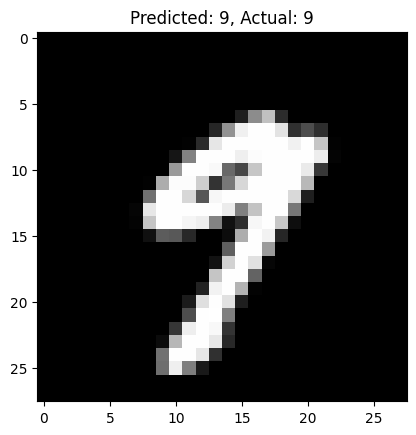

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load model
model = tf.keras.models.load_model("../models/mnist_model.h5")

# Load test data
test_data = pd.read_csv("mnist_test.csv")

x_test = test_data.iloc[:, 1:].values / 255.0
y_test = test_data.iloc[:, 0].values

x_test = x_test.reshape(-1, 28, 28)

# Pick sample
index = 20
image = x_test[index]

# Predict
prediction = model.predict(image.reshape(1,28,28))
digit = np.argmax(prediction)

# Show result
plt.imshow(image, cmap='gray')
plt.title(f"Predicted: {digit}, Actual: {y_test[index]}")
plt.show()